In [1]:
# Importera alla bibliotek vi behöver
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [3]:
# Ladda in MNIST-datan från internet
mnist = fetch_openml("mnist_784", version=1, cache=True, as_frame=False)

# Separera bilder (X) och etiketter (y)
X = mnist["data"]    # 70 000 bilder, varje bild = 784 pixlar
y = mnist["target"]  # Etiketterna, siffrorna 0-9

print(f"X form: {X.shape}")
print(f"y form: {y.shape}")
print(f"Exempel på etiketter: {y[:10]}")

X form: (70000, 784)
y form: (70000,)
Exempel på etiketter: ['5' '0' '4' '1' '9' '2' '1' '3' '1' '4']


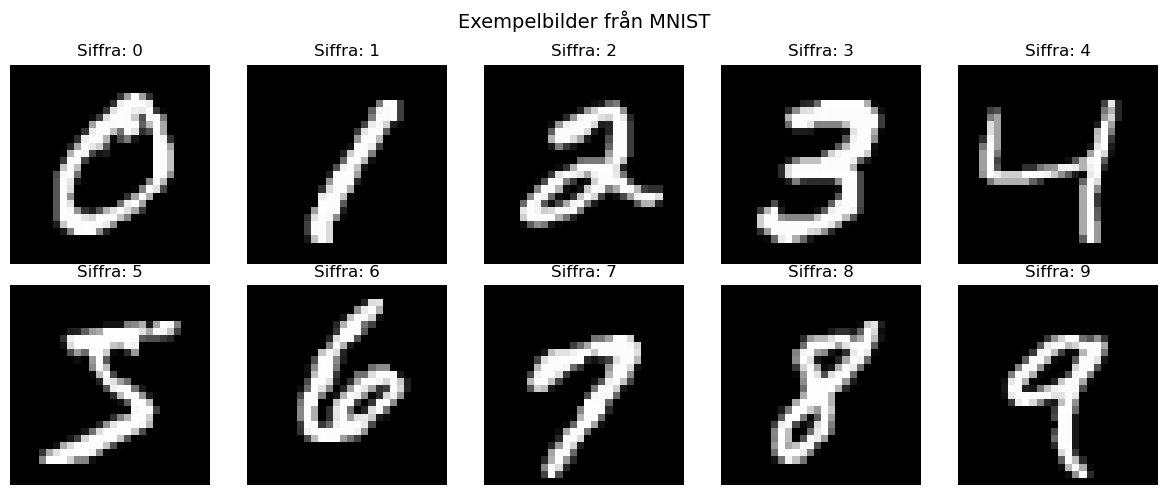

In [4]:
# Visa en exempelbild så vi förstår hur datan ser ut
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Exempelbilder från MNIST", fontsize=14)

for siffra in range(10):
    # Hitta första bilden för varje siffra (0-9)
    index = np.where(y == str(siffra))[0][0]
    
    # Omforma från 784 pixlar till 28x28 bild
    bild = X[index].reshape(28, 28)
    
    ax = axes[siffra // 5][siffra % 5]
    ax.imshow(bild, cmap="gray")
    ax.set_title(f"Siffra: {siffra}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [5]:
# MNIST har en standarduppdelning:
# De första 60 000 bilderna = träningsdata
# De sista 10 000 bilderna = testdata
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

print(f"Träningsdata: {X_train.shape}")
print(f"Testdata:     {X_test.shape}")

Träningsdata: (60000, 784)
Testdata:     (10000, 784)


In [6]:
# Standardisera pixelvärdena (0-255 → medelvärde 0, standardavvikelse 1)
scaler = StandardScaler()

# fit_transform på träningsdata - lär sig medelvärde och standardavvikelse
X_train_scaled = scaler.fit_transform(X_train)

# transform på testdata - använder SAMMA scaler som träningsdatan
X_test_scaled = scaler.transform(X_test)

print("Skalning klar!")
print(f"Medelvärde före skalning: {X_train[0].mean():.1f}")
print(f"Medelvärde efter skalning: {X_train_scaled[0].mean():.4f}")

Skalning klar!
Medelvärde före skalning: 35.1
Medelvärde efter skalning: 0.0512


In [7]:
# Vi använder ett urval på 5000 bilder för korsvalidering
URVAL = 5000
X_cv = X_train_scaled[:URVAL]
y_cv = y_train[:URVAL]

print(f"Korsvalideringsdata: {X_cv.shape}")
print(f"Antal bilder per siffra (ungefär): {URVAL // 10}")

Korsvalideringsdata: (5000, 784)
Antal bilder per siffra (ungefär): 500


In [8]:
# Modell 1: Logistisk Regression
# En linjär modell som klassificerar baserat på sannolikhet
modell_lr = LogisticRegression(
    max_iter=200,     # Max antal iterationer för att konvergera
    solver="saga",    # Effektiv solver för stora dataset
    random_state=42   # För reproducerbarhet
)

# Modell 2: Random Forest
# Många beslutsträd som röstar tillsammans
modell_rf = RandomForestClassifier(
    n_estimators=100,  # Antal träd i skogen
    random_state=42,
    n_jobs=-1          # Använd alla CPU-kärnor
)

# Modell 3: SVM (Support Vector Machine)
# Hittar det bästa hyperplanet som separerar klasserna
modell_svm = SVC(
    kernel="rbf",    # Radiell basfunktion - bra för bilder
    C=5,             # Regulariseringsparameter
    gamma="scale",   # Automatisk skalning
    random_state=42
)

print("Tre modeller definierade:")
print("  1. Logistisk Regression")
print("  2. Random Forest")
print("  3. SVM (RBF kernel)")

Tre modeller definierade:
  1. Logistisk Regression
  2. Random Forest
  3. SVM (RBF kernel)


In [9]:
# Jämför modellerna med 5-fold korsvalidering
# Datan delas i 5 delar, modellen tränas 5 gånger
# Varje gång används en annan del som validering

modeller = {
    "Logistisk Regression": modell_lr,
    "Random Forest":        modell_rf,
    "SVM (RBF kernel)":     modell_svm,
}

cv_resultat = {}

for namn, modell in modeller.items():
    print(f"Tränar: {namn}...")
    
    scores = cross_val_score(
        modell, X_cv, y_cv,
        cv=5,             # 5-fold korsvalidering
        scoring="accuracy",
        n_jobs=-1
    )
    
    cv_resultat[namn] = scores
    print(f"  Accuracy per fold: {scores.round(4)}")
    print(f"  Medel: {scores.mean():.4f} ± {scores.std():.4f}\n")

Tränar: Logistisk Regression...


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


  Accuracy per fold: [0.88  0.873 0.899 0.917 0.902]
  Medel: 0.8942 ± 0.0158

Tränar: Random Forest...
  Accuracy per fold: [0.931 0.931 0.936 0.937 0.93 ]
  Medel: 0.9330 ± 0.0029

Tränar: SVM (RBF kernel)...
  Accuracy per fold: [0.92  0.919 0.928 0.942 0.917]
  Medel: 0.9252 ± 0.0092



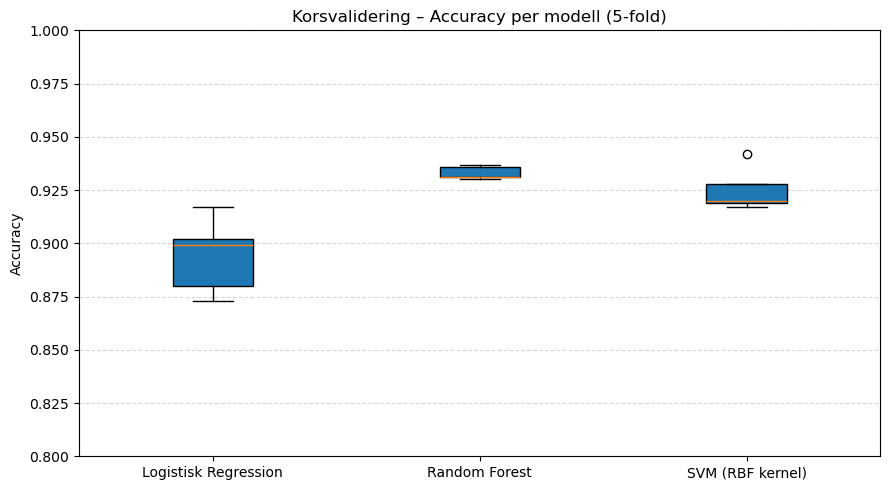

In [11]:
# Fixa varningen - öka max_iter för Logistisk Regression
modell_lr.max_iter = 1000

# Visualisera korsvalideringsresultaten
fig, ax = plt.subplots(figsize=(9, 5))

namn_lista = list(cv_resultat.keys())
scores_lista = list(cv_resultat.values())

ax.boxplot(scores_lista, tick_labels=namn_lista, patch_artist=True)
ax.set_title("Korsvalidering – Accuracy per modell (5-fold)")
ax.set_ylabel("Accuracy")
ax.set_ylim(0.8, 1.0)
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [12]:
# Random Forest hade högst accuracy i korsvalideringen
# Nu tränar vi om den på HELA träningsdatan (60 000 bilder)
print("Tränar Random Forest på all träningsdata...")
modell_rf.fit(X_train_scaled, y_train)

# Predicera på testdata
y_pred = modell_rf.predict(X_test_scaled)

# Beräkna accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy på testdata: {accuracy:.4f} ({accuracy*100:.2f}%)")

Tränar Random Forest på all träningsdata...

Accuracy på testdata: 0.9692 (96.92%)


In [13]:
# Classification report visar precision, recall och F1 per siffra
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.97      0.96      1032
           3       0.96      0.96      0.96      1010
           4       0.98      0.97      0.97       982
           5       0.97      0.96      0.97       892
           6       0.98      0.97      0.98       958
           7       0.97      0.96      0.97      1028
           8       0.96      0.95      0.96       974
           9       0.95      0.96      0.95      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



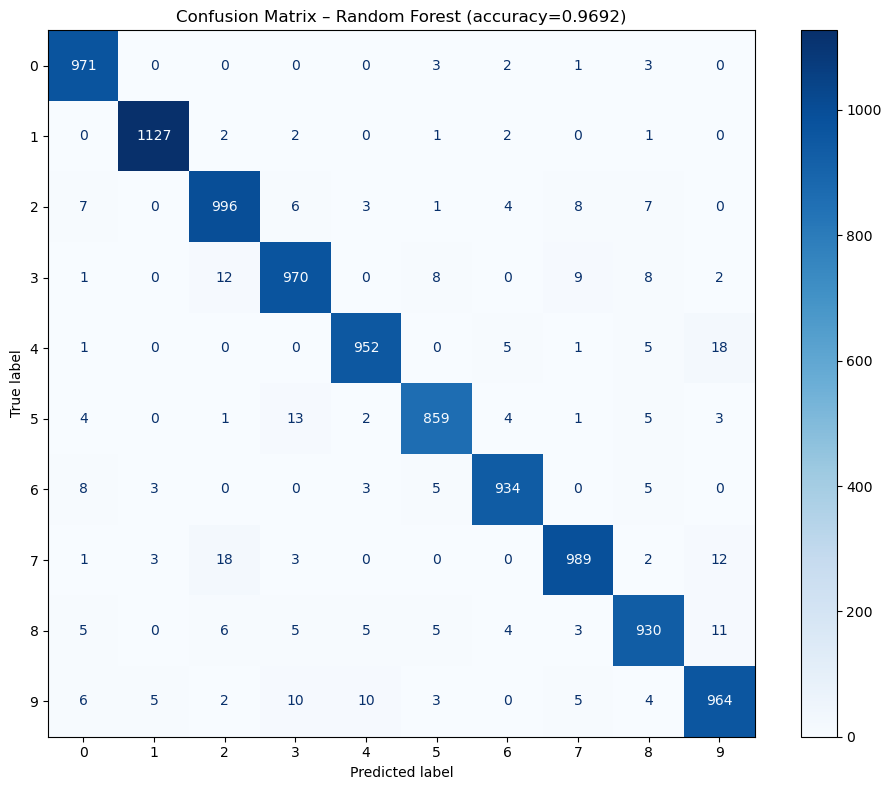

In [14]:
# Confusion matrix visar exakt var modellen gör fel
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, colorbar=True, cmap="Blues")

ax.set_title(f"Confusion Matrix – Random Forest (accuracy={accuracy:.4f})")
plt.tight_layout()
plt.show()

Antal felklassificerade bilder: 308 av 10000


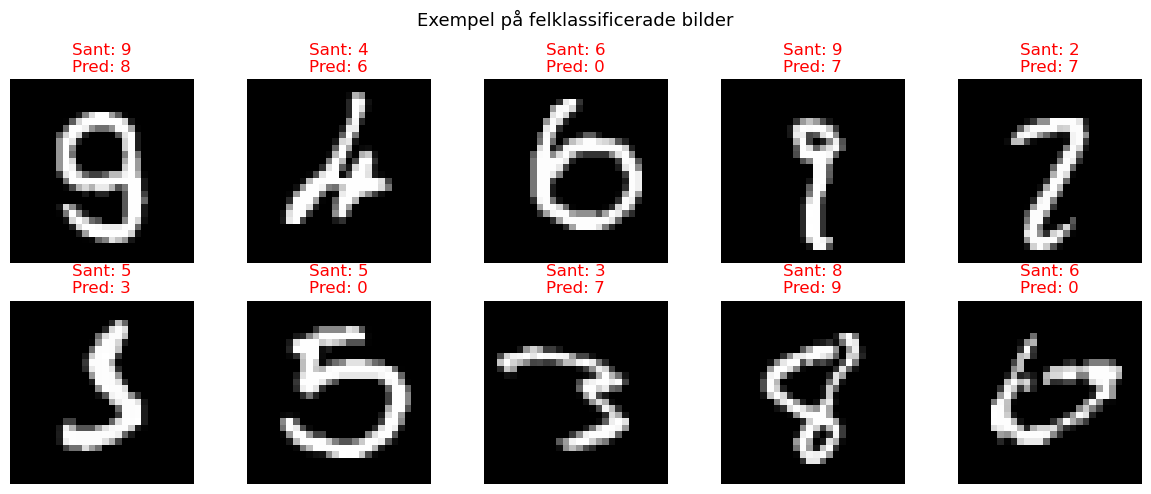

In [15]:
# Hitta bilder som modellen klassificerade fel
fel_index = np.where(y_pred != y_test)[0]
print(f"Antal felklassificerade bilder: {len(fel_index)} av {len(y_test)}")

# Visa 10 exempel på felklassificerade bilder
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Exempel på felklassificerade bilder", fontsize=13)

for i, idx in enumerate(fel_index[:10]):
    bild = X_test[idx].reshape(28, 28)
    sant_label = y_test[idx]
    pred_label = y_pred[idx]
    
    ax = axes[i // 5][i % 5]
    ax.imshow(bild, cmap="gray")
    ax.set_title(f"Sant: {sant_label}\nPred: {pred_label}", color="red")
    ax.axis("off")

plt.tight_layout()
plt.show()


## Del 1 - Teoretiska Frågor

### Fråga 1: Förklara vad AI, ML respektive DL är och relationen mellan begreppen.
AI (Artificiell Intelligens) är det bredaste begreppet och syftar på alla system eller maskiner som kan utföra uppgifter som normalt kräver mänsklig intelligens. Det kan handla om att förstå språk, känna igen bilder, fatta beslut eller lösa problem. AI är ett paraplybegrepp som innefattar många olika tekniker och metoder.
ML (Maskininlärning) är en delmängd av AI. Istället för att programmeraren skriver explicita regler för hur systemet ska bete sig, låter man maskinen lära sig mönster från data. En ML-modell tränas på historisk data och lär sig sedan generalisera till ny, osedd data. Exempel: en modell tränas på tusentals e-post och lär sig skilja spam från icke-spam.
DL (Djupinlärning) är en delmängd av ML som använder artificiella neurala nätverk med många lager (därav "djup"). DL är särskilt kraftfullt för komplexa data som bilder, ljud och text, och ligger bakom moderna genombrott som bildigenkänning och ChatGPT.


### Fråga 2: Julia delar upp sin data i träning och test. På träningsdatan så tränar hon tre modeller; "Linjär Regression", "Lasso regression" och en "Random Forest modell". Hur skall hon välja vilken av de tre modellerna hon skall fortsätta använda när hon inte skapat ett explicit "valideringsdataset"?
Lösningen är att använda korsvalidering (cross-validation).
Korsvalidering innebär att träningsdatan delas upp i k lika stora delar. Modellen tränas k gånger — varje gång används en annan fold som valideringsdata och resten som träningsdata. Slutligen beräknas medelvärdet av prestandan över alla folds.
Julia bör alltså:
Köra korsvalidering på träningsdatan för alla tre modeller
Jämföra deras genomsnittliga accuracy (eller annat relevant mått)
Välja modellen med bäst och mest stabilt resultat
Träna om den valda modellen på hela träningsdatan
Slutligen utvärdera en enda gång på testdatan


### Fråga 3: Vad är "regressionsproblem"? Kan du ge några exempel på modeller som används och potentiella tillämpningsområden?
Ett regressionsproblem är ett problem där målet är att predicera ett kontinuerligt numeriskt värde. Till skillnad från klassificering (som predicerar en kategori) predicerar regression ett tal på en skala.
Exempel på regressionsproblem:
Predicera priset på ett hus baserat på storlek, läge och antal rum
Förutsäga en persons lön baserat på utbildning och erfarenhet
Estimera hur mycket energi ett hus förbrukar
Några modeller som används:
Linjär Regression – den enklaste, passar en linje till datan
Lasso Regression – linjär regression med extra kontroll så modellen inte blir för komplex
Random Forest Regression – använder många beslutsträd för att göra en prediktion
Tillämpningsområden: huspriser, aktiekurser, energiförbrukning, löneprediktion.


### Fråga 4: Antag att vi har följande regressionsmodell: Y = β0 + β1X + ε, vad kallas Y, X, βi och ε?
Modellen: Y = β₀ + β₁X + ε
Y kallas beroende variabel, responsvariabel eller målvariabel. Det är det vi försöker predicera (t.ex. husets pris).
X kallas oberoende variabel, förklaringsvariabel eller feature. Det är den variabel vi använder för att göra predicktionen (t.ex. husets storlek).
β₀ kallas intercept eller konstant. Det är värdet på Y när X = 0. Geometriskt är det där linjen skär y-axeln.
β₁ kallas koefficient eller lutning. Det beskriver hur mycket Y förändras när X ökar med en enhet. Om β₁ = 50 000 betyder det att priset ökar med 50 000 kr per extra kvadratmeter.
βi generellt kallas parametrar eller modellkoefficienter. De är de okända fasta värden som skattas från datan.
ε kallas feltermen, residualen eller brusterm. Den fångar upp allt som modellen inte kan förklara — mätfel, slumpmässig variation och effekter av variabler som inte ingår i modellen. Man antar ofta att ε ~ N(0, σ²).


### Fråga 5: Hur kan du tolka RMSE och vad används det till?
RMSE visar hur stora fel modellen gör i genomsnitt. Det bra med RMSE är att svaret kommer i samma enhet som det vi försöker förutsäga. Om vi förutsäger huspriser i kronor och RMSE är 200 000 kr, betyder det att modellen i snitt gissar fel med ungefär 200 000 kr.
Ju lägre RMSE desto bättre modell. Man använder det framförallt för att jämföra olika modeller mot varandra och välja den bästa.


### Fråga 6: Vad är "klassificieringsproblem"? Kan du ge några exempel på modeller som används och potentiella tillämpningsområden?
Ett klassificeringsproblem är ett problem där målet är att predicera vilken kategori (klass) ett objekt tillhör. Svaret är ett av ett ändligt antal möjliga klasser.
Typer:
Binär klassificering: två klasser (t.ex. spam/inte spam, sjuk/frisk)
Flerklassklassificering: fler än två klasser (t.ex. siffror 0–9 i MNIST)

Exempel på klassificeringsproblem:
Är detta e-post spam eller inte?
Vilken siffra föreställer den här bilden?
Har patienten cancer eller inte?
Vilket djur finns på bilden?

Vanliga modeller:
Logistisk Regression – trots namnet används den för klassificering
Random Forest – många träd som röstar om svaret
SVM – hittar den bästa gränsen mellan klasserna

Tillämpningsområden: skräppostfilter, cancerdiagnostik, bildigenkänning, ansiktsigenkänning.


### Fråga 7: Vad är en "Confusion Matrix"?
En confusion matrix är en tabell som visar hur bra en klassificeringsmodell är. Den jämför vad modellen gissade med vad svaret faktiskt var.
Den visar fyra saker:
TP (True Positive): Modellen sa ja och det stämde
TN (True Negative): Modellen sa nej och det stämde
FP (False Positive): Modellen sa ja men det var fel
FN (False Negative): Modellen sa nej men det var fel
Det är användbart för att se exakt var modellen gör fel, inte bara hur många procent den får rätt totalt.


### Fråga 8: Hur definieras Precision? Hur tolkas Precision?
Precision räknas ut så här: TP / (TP + FP)
Det svarar på frågan: av alla gånger modellen sa "ja", hur många gånger hade den rätt?
Om ett spamfilter flaggar 100 mail som spam och 90 av dem faktiskt är spam, är precisionen 90%. Hög precision betyder att modellen inte larmar i onödan. Det är viktigt när det är jobbigt att ha falska larm, till exempel om man inte vill att vanliga mail hamnar i skräppost.


### Fråga 9: Hur definieras Recall? Hur tolkas Recall?
Recall räknas ut så här: TP / (TP + FN)
Det svarar på frågan: av alla som faktiskt är positiva, hur många hittade modellen?
Om det finns 100 sjuka patienter och modellen hittar 80 av dem, är recall 80%. De andra 20 missades helt. Hög recall är viktigt när det är farligt att missa ett positivt fall, till exempel vid sjukdomsdiagnostik.
Precision och recall hänger ihop – oftast om man förbättrar den ena försämras den andra lite.


### Fråga 10: Göran påstår att datan antingen är "ordinal" eller "nominal". Julia säger att detta måste tolkas. Hon ger ett exempel med att färger såsom {röd, grön, blå} generellt sett inte har någon inbördes ordning (nominal) men om du har en röd skjorta så är du vackrast på festen (ordinal) – vem har rätt?
Julia har rätt. Det går inte att säga att data alltid är det ena eller det andra utan att tänka på sammanhanget.
Nominal data har kategorier utan någon ordning, som färger eller nationalitet. Ordinal data har kategorier med en ordning, som betyg eller placeringen i en tävling.
Julias exempel visar att samma data kan vara nominal i ett sammanhang och ordinal i ett annat. Det beror helt på hur man använder och tolkar datan.


### Fråga 11: Vad är skillnaden mellan parametrar och hyperparametrar i en maskininlärningsmodell? Ge ett exempel på varje och förklara varför de inte kan optimeras på samma sätt.
Parametrar är värden som modellen lär sig själv under träningen. Ett exempel är koefficienterna i linjär regression, alltså β-värdena. Modellen justerar dem automatiskt för att passa datan.
Hyperparametrar är värden som vi bestämmer innan träningen börjar. Ett exempel är antal träd i en Random Forest. Det är vi som väljer det, inte modellen.
De kan inte optimeras på samma sätt eftersom parametrar optimeras matematiskt under träningen, medan hyperparametrar måste testas manuellt, till exempel genom att prova olika värden och se vilket som ger bäst resultat med korsvalidering.


### Fråga 12: Förklara skillnaden mellan overfitting och underfitting i en maskininlärningsmodell. Beskriv även hur man kan upptäcka respektive åtgärda dem.
Underfitting betyder att modellen är för enkel. Den lär sig inte tillräckligt mycket från datan och gör dåliga prediktioner både på tränings- och testdata.
Overfitting betyder att modellen är för komplex. Den lär sig träningsdatan utantill, inklusive brus och slump, men fungerar dåligt på ny data.
Hur man upptäcker dem:
Underfitting: både träningsfel och testfel är höga
Overfitting: träningsfelet är lågt men testfelet är högt
Hur man åtgärdar:
Underfitting: använd en mer komplex modell eller lägg till fler features
Overfitting: använd regularisering, mer träningsdata eller en enklare modell


### Fråga 13: Hur funkar OvO och OvR algoritmerna?
Dessa används när man vill använda en binär klassificerare (som bara klarar två klasser) på ett problem med många klasser.
OvR (One vs Rest): Man tränar en klassificerare per klass. Varje klassificerare lär sig skilja sin klass från alla andra. Med 10 klasser får man 10 klassificerare. Den som är mest säker vinner.
OvO (One vs One): Man tränar en klassificerare för varje par av klasser. Med 10 klasser blir det 45 klassificerare. Alla röstar och klassen med flest röster vinner.
OvR är vanligare eftersom det kräver färre modeller. OvO tränar på mindre data åt gången vilket kan vara snabbare i vissa fall.


### Fråga 14: Vad är intuitionen bakom att regularisera en modell?
Regularisering är en teknik för att förhindra overfitting genom att straffa komplexa modeller. Intuitionen är: en enklare modell generaliserar ofta bättre till ny data än en som memorerat träningsdatan.
Tekniskt lägger man till en straffterm till kostnadsfunktionen som ökar när modellens koefficienter blir stora. Modellen tvingas då hitta en balans mellan att passa träningsdatan och att hålla koefficienterna små.
Två vanliga typer:
L1-regularisering (Lasso): Straffar summan av absolutvärdet av koefficienterna. Kan krympa vissa koefficienter till exakt noll → automatisk feature selection.
L2-regularisering (Ridge): Straffar summan av kvadraten av koefficienterna. Krymper alla koefficienter men sällan till noll.
Intuition med ett exempel:
Tänk dig en kurva som perfekt följer alla träningspunkter med vilda svängar (overfitting). Regularisering "glättar" kurvan och tvingar den att vara enklare, även om den inte träffar varje punkt exakt.


### Fråga 15: Vad är Bias Variance Trade-off?
Bias handlar om hur mycket modellen missar på grund av att den är för enkel. Hög bias betyder underfitting.
Variance handlar om hur känslig modellen är för förändringar i träningsdatan. Hög variance betyder overfitting.
Problemet är att dessa två hänger ihop. Om man gör modellen mer komplex minskar bias men variance ökar, och tvärtom.
Målet är att hitta en balans där varken bias eller variance är för hög, alltså den punkt där modellen gör minst fel totalt sett på ny data.


### Fråga 16: Varför är mer komplexa modeller inte alltid bättre?
Det finns flera anledningar:
En komplex modell kan lära sig träningsdatan för bra och sedan fungera dåligt på ny data, det vill säga overfitting.
Dessutom är komplexa modeller svårare att förstå och förklara. I många situationer är det viktigt att kunna motivera varför modellen tog ett visst beslut.
De kräver också mer beräkningskraft och tid att träna, och de behöver mycket mer data för att fungera bra.
Ibland är en enkel modell tillräckligt bra och mycket lättare att jobba med. Mer komplex betyder alltså inte automatiskt bättre.


### Fråga 17: Kan du kort förklara hur fixa men okända parametrarna β0, β1, …, βp skattas med hjälp av MSE?
MSE mäter hur stora felen är i genomsnitt. Målet är att hitta de β-värden som gör MSE så litet som möjligt, alltså att modellens prediktioner ligger så nära de verkliga värdena som möjligt.
Det görs antingen matematiskt genom att sätta derivatan av MSE till noll och lösa ekvationen, eller numeriskt med gradient descent där man tar små steg i den riktning som minskar MSE mest tills man hittar minimumet.


### Fråga 18: I frågan ovan, varför används MSE och inte RMSE? Vad är skillnaden?
RMSE är bara kvadratroten av MSE. De minimeras av exakt samma β-värden, så det spelar ingen roll matematiskt vilket man använder för att hitta parametrarna.
Men MSE är enklare att derivera eftersom det inte har en kvadratrot, och det är det som gör det praktiskt att använda vid optimering.
RMSE används däremot när man vill tolka och kommunicera resultaten, eftersom det är i samma enhet som målvariabeln och därmed lättare att förstå i praktiken.


### Fråga 19: Vad betyder övervakad respektive oövervakad maskininlärning?
Övervakad inlärning betyder att vi tränar modellen på data där vi redan vet svaret. Till exempel bilder av siffror där vi vet vilken siffra varje bild föreställer. Modellen lär sig kopplingen mellan input och rätt svar. MNIST är ett exempel på detta.
Oövervakad inlärning betyder att vi tränar modellen på data utan några kända svar. Modellen får hitta mönster och strukturer på egen hand, till exempel gruppera kunder i segment utan att vi berättar vilka grupper som finns.


### Fråga 20: Vad är prediktions- respektive konfidensintervall? Vilket intervall är bredast och varför?
Konfidensintervall visar var medelvärdet för en grupp troligen ligger. Till exempel: vi är 95% säkra på att det genomsnittliga huspriset för 100 kvm hus ligger mellan 3,2 och 3,8 miljoner.
Prediktionsintervall visar var ett enskilt nytt värde troligen hamnar. Till exempel: vi är 95% säkra på att just detta 100 kvm hus kostar mellan 2,5 och 4,5 miljoner.
Prediktionsintervallet är alltid bredast eftersom det innehåller två osäkerhetskällor: osäkerheten i modellens skattning plus den naturliga variationen hos enskilda observationer. Konfidensintervallet tar bara hänsyn till den första.

